# Maquina de vector soporte - Support vector machine
Nicole Chavarria

In [1]:
import pandas as pd
from sklearn import datasets
from sklearn import svm

import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn

In [2]:
data = sklearn.datasets.make_blobs(n_samples=1000,             # número de datos a generar.
                                   n_features=2,               # número de factores.
                                   centers=[(-4,-4),(4,4)],    # coordenadas de los centros de las dos clases a generar.
                                   cluster_std=1.,            # desviación estándar de cada cúmulo generado.
                                   random_state=10)

In [3]:
X, y = data
#y = y.reshape(y.shape[0],1)

print(X.shape)
print(y.shape)

(1000, 2)
(1000,)


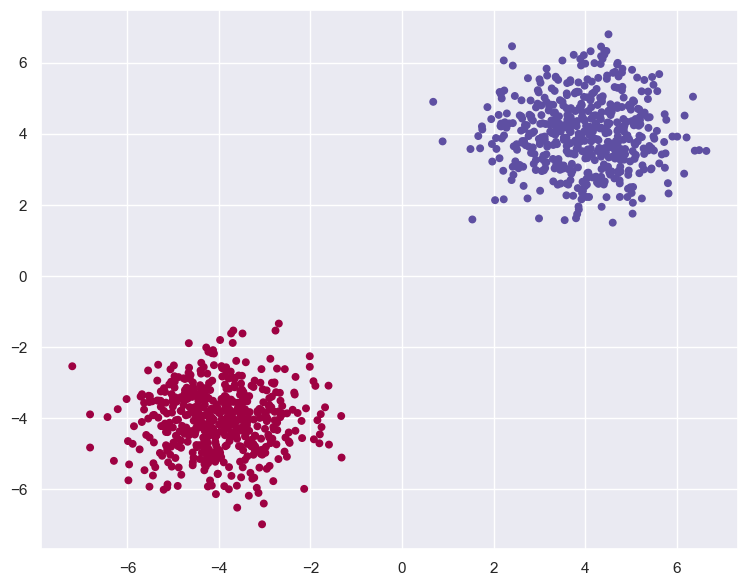

In [4]:
sns.set(rc={'figure.figsize':(9,7)})   # (width, height) - definiendo el tamaño del canvas.
plt.scatter(X[:,0], X[:,1], c=y, s=22, cmap=plt.cm.Spectral);

In [5]:
print(X[:5,:])

[[ 4.52703933  2.91738139]
 [ 4.39524952  3.50592185]
 [-3.01340218 -3.97177263]
 [-4.19410253 -5.74673584]
 [ 3.23864646  4.05911423]]


In [6]:
print(y[:5])

[1 1 0 0 1]


## 1.1 Modelo lineal - Hiperplano separador: Conjuntos linealmente separables

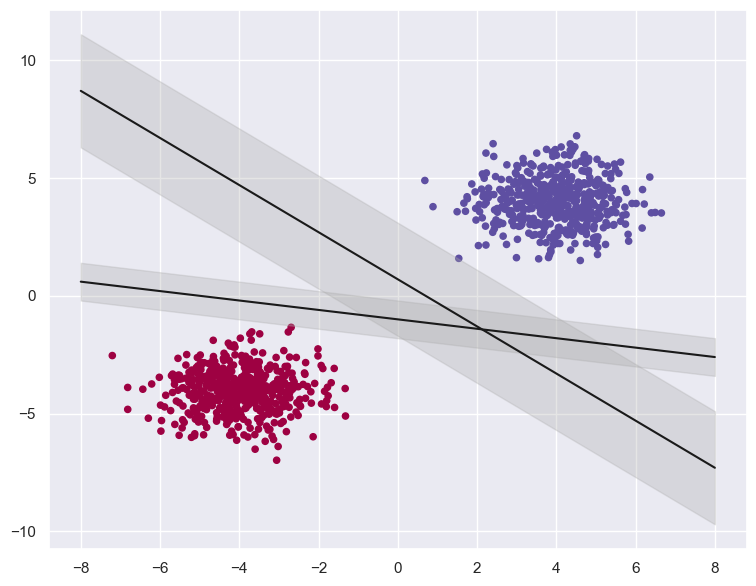

In [7]:
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap=plt.cm.Spectral);  # Gráfico de dispersión de ambas clases

# Y dibujamos dos hiperplanos-clasificadores lineales, con sus márgenes de separación.
# Estos dos hiperplanos son arbitrario y solo para fines ilustrativos.
xhs = np.linspace(-8, 8,)   # generamos un conjunto de 50 puntos entre -8 y 8.
for m, b, d in [(-1, 0.7, 2.4),  (-0.2, -1, 0.8)]:      # (m,b,d) --> m: pendientes  /  b: ordenadas en el origen   /  d: margen máximo
    yhs = m * xhs + b
    plt.plot(xhs, yhs, '-k');
    plt.fill_between(xhs, yhs - d, yhs + d, edgecolor='none',color='#AAAAAA', alpha=0.3);  # márgenes máximos de cada HiperplanoSeparador

Funcion para definir los vectores de soporte con sus hiperplanos de margen maximo:


In [8]:
# Definimos una función para visualizar los hiperplanos separadores e identicar los vectores de soporte.
# Esto es para fines ilustrativos del ejemplo, pero que nos ayudará a entender mejor la manera que el
# modelo SVM funciona, así como algunos de sus principales hiperparámetros.

def plot_svc_decision_function(model, 
                               ax=None, 
                               plot_support=True     # para indicar si quieres resaltar los vecotres de soporte
                               ):    

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()   # intervalo (puntos máximo y mínimo) en el cual varían todos los registros.
    ylim = ax.get_ylim()

    
    # generemos nuestro grid de valores en los cuales estaremos evaluando:
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    
    xy = np.vstack([X.ravel(), Y.ravel()]).T    # ravel convierte cada uno a 1-D.

    P = model.decision_function(xy).reshape(X.shape)  # "decision_function" genera predicciones sobre a qué clase asigna cada punto del grid.
    
    # dibuja el hiperplano y sus fonteras de margen máximo
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '-.'])    # para distinguir entre cada hiperplano

    
    # resaltemos de amarillo los vectores de soporte:
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=400, facecolors='yellow', alpha=0.3);    # coloreamos de amarillo cada vector de soporte.
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

Kernel lineal : hiperplano separardor maximo (HMM) - caso linealmente separable

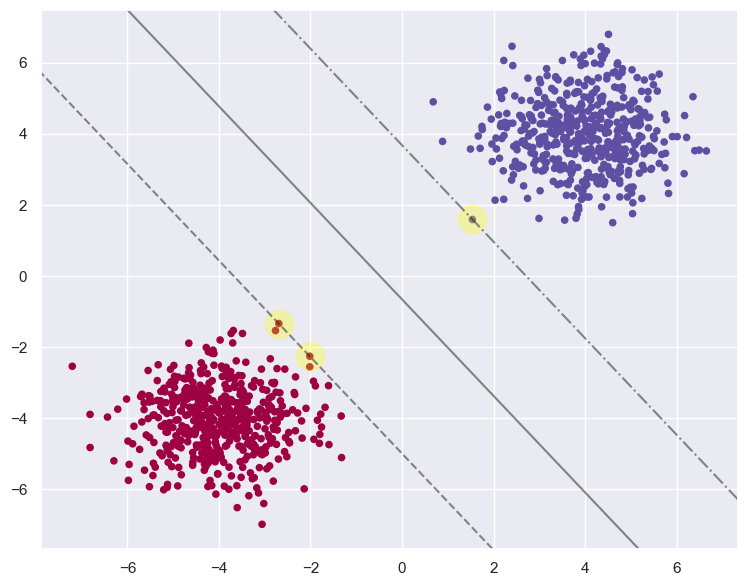

In [9]:
# Parámetro de regularización C
# A medida que disminuye C, la región de separación aumenta y datos de ambas clases quedan dentro de dicha región.
# Esto permitiría mayor tolerancia al ruido por parte del modelo.
# Por otro lado, mayor valor de C, más angosta la región de separación, o hasta donde haya datos de cada clase.

model = svm.SVC(kernel='linear',    # usando el kernel lineal
                C=1.    # C=1000, 1, 0.1, 0.01         # Parámetro de regularización L2.
                )                                    # Más pequeño el valor de C, más ancho el margen de separación,
                                                     # aunque algunos puntos ya queden dentro del margen de separación.
                                                 

model.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap=plt.cm.Spectral)  
plot_svc_decision_function(model);

In [10]:
model.support_vectors_   # vectores de soporte entrenado

array([[-2.69151285, -1.33742253],
       [-2.01491541, -2.25518585],
       [ 1.53777742,  1.58876843]])

In [11]:
model.support_ #indices de los vectores de soporte entrenado

array([205, 680, 850], dtype=int32)

# 1.2 Kernel radial o funcion de base radial(RBF) radial basis function : conjuntos separables linealmente

parametro C es de regularacion y gamma es el radio de influencia de los vectores soporte

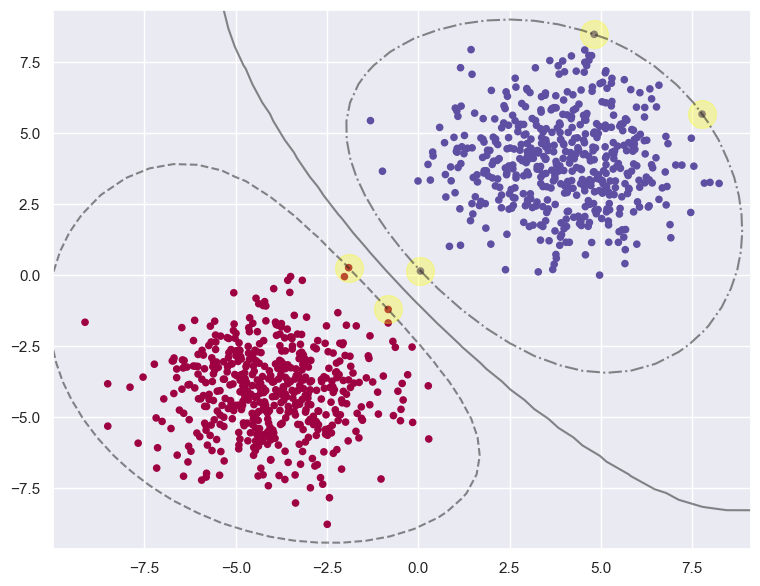

In [12]:
# Ejemplos de SVM-RBF con Gamma constante y haciendo variar C:

N=1000
noisy_data = sklearn.datasets.make_blobs(n_samples=N, n_features=2, centers=[(-4,-4),(4,4)], cluster_std=1.6, random_state=10)
X, y = noisy_data

# A medida que disminuye C, podríamos decir que "se contrae" la frontera de vectores de soporte y generalmente aumentan,
# ya que se introduce en una región más densa de observaciones. 
# Aunque para el caso de clases seprables siguen quedando bien clasificados.
# Así, como al disminuir el valor de C se incrementa el número de vectores de soporte, 
# se hace más costoso el tiempo de ejecución del modelo.

model = svm.SVC(kernel='rbf', C=100.)       # intentar estos valores de C=100, 10, 1, 0.5, 0.1, .01
                                            # gamma=default (fijo),  
model.fit(X, y) 

plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap=plt.cm.Spectral)  
plot_svc_decision_function(model);

# 1.3 SVM -RBF : conjuntos separables, pero no linealmente

El valor predeterminado de gamma es inversamente proporcional a la varianza de los datos de entrenamiento

In [13]:
X.var()  # varianza de los datos, para tener una idea de la dispersión de los datos.

np.float64(18.414939889215486)

In [14]:
1/(2*X.var())  # valor de gamma que se recomienda usar para este conjunto de datos.

np.float64(0.027151867071410846)

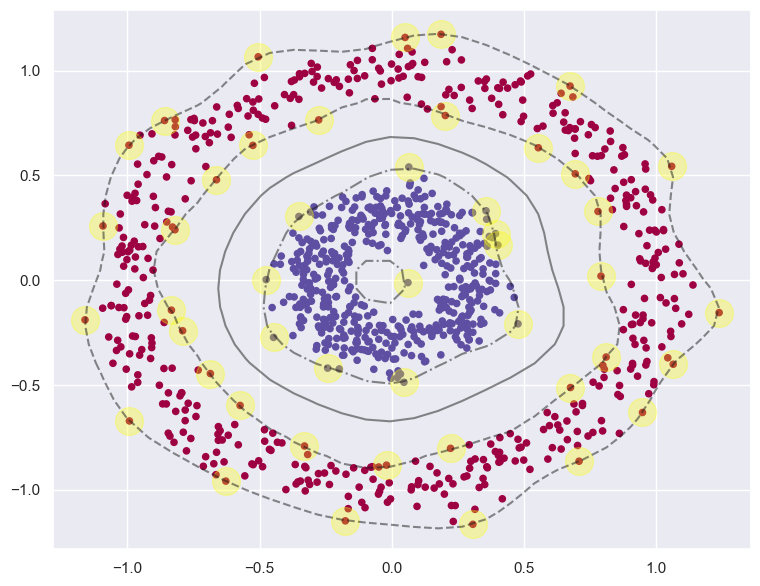

In [15]:
# Ejemplos de SVM-RBF con  C constante, y ahora hacemos variar gamma (radio de influencia):

N=1000   
noisy_data = sklearn.datasets.make_circles(n_samples=N, 
                                           factor = 0.3,   # factor de separación entre los círculos
                                           noise=0.08,
                                           random_state=10)

X, y = noisy_data

# En este caso de conjuntos separables radialmente.
# A medida que gamma se hace más grande (con C constante) más irregulares las fronteras separadoras y se va generando overfitting. 
# Es decir, gamma más grandes significa radio de influencia más pequeña o cercana y por ello más irregular. 
# Cuando se habla de "radio" en realidad es el "radio de curvatura de la frontera en cada vector de soporte. 
# Radios pequeños (gamma pequeño) equivale a mayor irregularidad.

model = svm.SVC(kernel='rbf', 
                C=10,       # mantengamos C con este valor constante, fijo.
                gamma=10      # Ahora intentar estos valores de gamma= .05, 0.1, 1, 10, 30, 50
                )    
model.fit(X, np.ravel(y))

plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap=plt.cm.Spectral)  
plot_svc_decision_function(model);

## 1.4 : SVM - RBF : conjuntos linealmente no separables

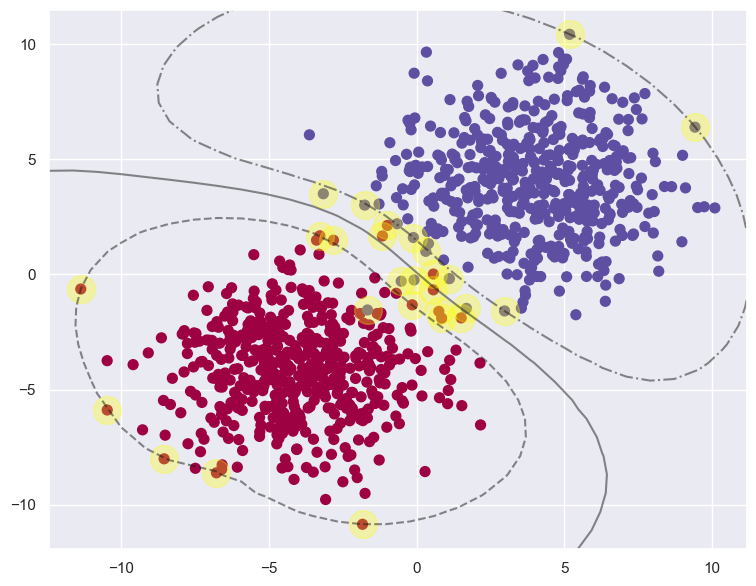

In [16]:
N=1000
noisy_data2 = sklearn.datasets.make_blobs(n_samples=N, n_features=2, centers=[(-4,-4),(4,4)], cluster_std=2.3, random_state=10)  

X2, Y2 = noisy_data2


# En el caso lineal, por más grande que sea el valor de C, ya hay puntos que están mal clasificados y no se modifican las fornteras.
# En el caso radial sí se podrían ir ajustando, aunque hay que cuidar el overfitting:

C =  10

modelnol = svm.SVC(kernel='rbf', C=C, gamma=0.03)     # intenta con kernel lineal y radial y varios casos de C y gamma
                                                     # Recuerda que gammas muy grandes pueden llevar al sobreentrenamiento.
modelnol.fit(X2, Y2)

plt.scatter(X2[:, 0], X2[:, 1], c=Y2, s=50, cmap=plt.cm.Spectral)
plot_svc_decision_function(modelnol)

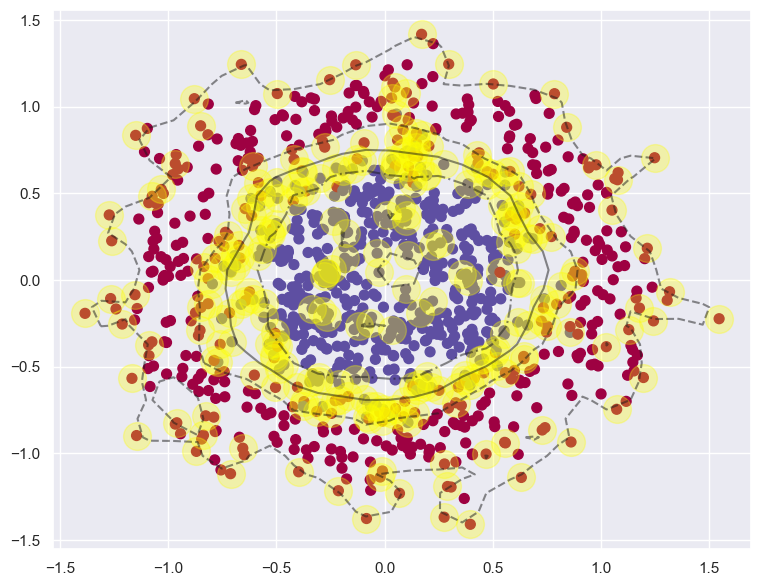

In [17]:
# En el caso lineal, por más grande que sea el valor de C, ya hay puntos que están mal clasificados y no se modifican las fornteras.
# En el caso radial sí se podrían ir ajustando, aunque hay que cuidar el overfitting:

N=1000   
noisy_data = sklearn.datasets.make_circles(n_samples=N, 
                                           factor = 0.4,   # factor de separación entre los círculos
                                           noise=0.18,
                                           random_state=10)

X2, Y2 = noisy_data


C =  1
g = 20

modelnol = svm.SVC(kernel='rbf', C=C, gamma=g)     # intenta con kernel lineal y radial y varios casos de C y gamma
                                                     # Recuerda que gammas muy grandes pueden llevar al sobreentrenamiento.
modelnol.fit(X2, Y2)

plt.scatter(X2[:, 0], X2[:, 1], c=Y2, s=50, cmap=plt.cm.Spectral)
plot_svc_decision_function(modelnol)

### Jueves 13 seguimiento
# Parte 2 : Curva ROC


In [18]:
from sklearn import metrics 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

0.88


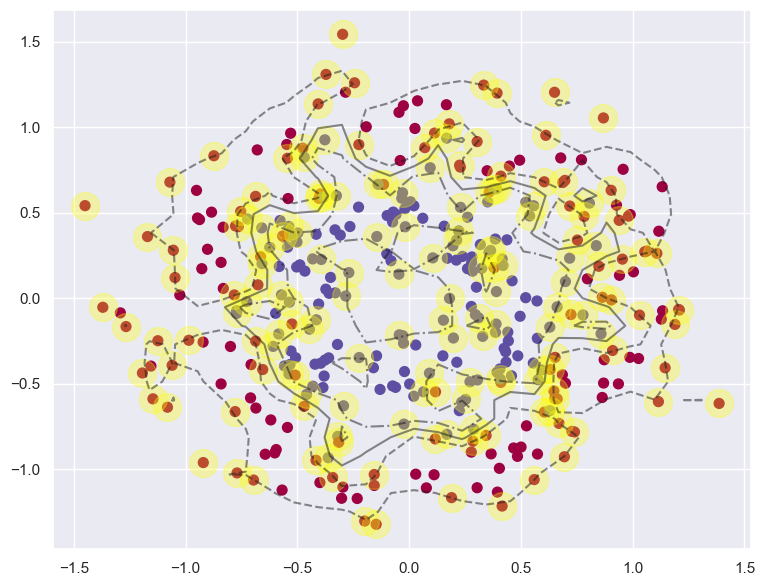

In [19]:
noisy_data = sklearn.datasets.make_circles(n_samples=500, factor=0.5,  noise=0.2, random_state=10)
X3, y3 = noisy_data
Xtrain, Xtest, ytrain, ytest = train_test_split(X3, y3, test_size=.3, shuffle=True, random_state=1)

modeloSVM = svm.SVC(kernel='rbf', C=10, gamma=35)     
                                                     
modeloSVM.fit(Xtrain, ytrain)

print(modeloSVM.score(Xtest, ytest))

plt.scatter(Xtrain[:, 0], Xtrain[:, 1], c=ytrain, s=50, cmap=plt.cm.Spectral)
plot_svc_decision_function(modeloSVM)

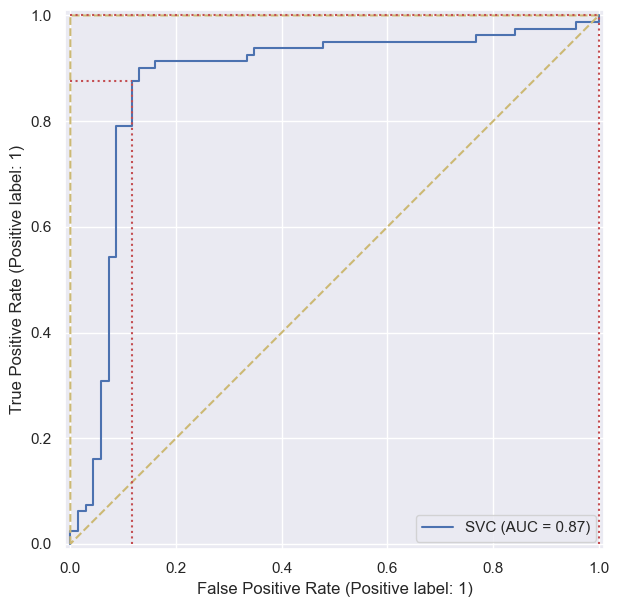

In [20]:
# Obtenemos las predicciones del modelo:
yhat = modeloSVM.predict(Xtest)

# Obtenemos la tasa de falsos positivos (fpr) y la tasa de verdaderos positivos (tpr):
fpr, tpr, _ = metrics.roc_curve(ytest, yhat)


metrics.RocCurveDisplay.from_estimator(modeloSVM, Xtest, ytest)

plt.plot([0,0,1,0],[0,1,1,0], 'y--')

plt.hlines(tpr, 0, fpr, colors='r', linestyles='dotted')  # Se calcula TPrate y FPrate con base a threshold=0.5
plt.vlines(fpr, 0, tpr, colors='r', linestyles='dotted')  # como valor predeteminado
plt.show()

In [21]:
modeloLR = LogisticRegression(max_iter=1000, C=.01).fit(Xtrain, ytrain)
modeloLR.score(Xtest, ytest)

0.46

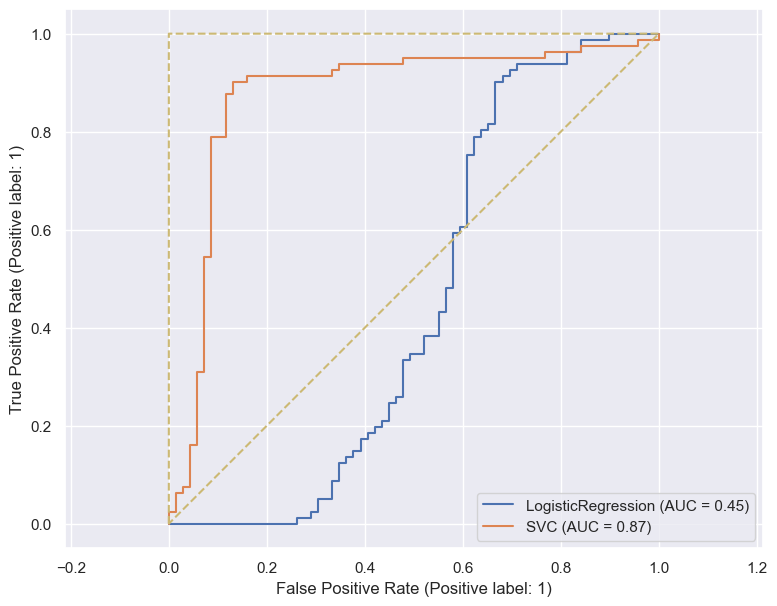

In [22]:
lr_curve = metrics.RocCurveDisplay.from_estimator(modeloLR, Xtest, ytest)
svm_curve = metrics.RocCurveDisplay.from_estimator(modeloSVM, Xtest, ytest, ax=lr_curve.ax_)

plt.plot([0,0,1,0],[0,1,1,0], 'y--')

 
plt.axis('equal')
plt.show()